# Agentic Scientist

**An LLM-powered agent that automates an end-to-end ML research workflow — from preprocessing a public medical-imaging dataset to a PDF report whose narrative paragraphs are written by the LLM itself.**

Everything runs locally: the LLM is Llama 3.2 (3B) served by [Ollama](https://ollama.com), so there are no API keys or cloud calls.

## Pipeline

| Step | Tool | What it does |
|------|------|--------------|
| 1 | `preprocess_data` | Download PneumoniaMNIST (MedMNIST), serialize as DataLoaders. |
| 2 | `train_model` | Train a DDPM with a ShuffleNet-based UNet. |
| 3 | `generate_samples` | Sample synthetic images via reverse diffusion. |
| 4 | `evaluate_samples` | Patch-MMD permutation test (real vs. generated). |
| 5 | `write_report_text` | LLM writes the report's narrative sections from the stats. |
| 6 | `create_report` | Assemble the PDF. |
| 7 | `run_pipeline` | Orchestrator that runs all of the above. |

Each tool is dispatched from a plain-English prompt by a [PydanticAI](https://ai.pydantic.dev) agent — typed schemas validate every call.

## What's new vs. v2

- **Public dataset.** Replaced the private dataset with PneumoniaMNIST (5,856 chest X-ray slices, CC-BY).
- **Permutation test rewritten.** Fixed bandwidth, p-value, sample collection, and the bogus "observed distribution". Sanity-checked under H0 and H1.
- **LLM-written report.** The model reads the actual stats and writes the introduction, descriptions, and conclusion. Falls back gracefully if generation fails.
- **Orchestrator tool.** End-to-end runs are no longer dependent on a small model chaining six tool calls.
- **Multiple LLM backends.** `AGENT_MODEL=ollama|ollama-qwen|groq|gemini|anthropic` with one env var.

---
# 1. Setup

## 1a. Get the repository

If you uploaded the zip into Colab, unzip it. Otherwise clone from GitHub.

In [ ]:
import os
if not os.path.isdir('agentic-science'):
    !unzip -q agentic-science-v3.zip -d agentic-science
%cd agentic-science
# If multiple top-level dirs got extracted, descend into the first one.
import glob
tops = [d for d in glob.glob('*') if os.path.isdir(d) and os.path.isfile(os.path.join(d, 'agent.py'))]
if tops:
    %cd $tops[0]
!pwd && ls

/content/agentic-science
[Errno 2] No such file or directory: '[agentic-science][0]'
/content/agentic-science
/content/agentic-science
agentic-science


In [ ]:
%cd agentic-science

/content/agentic-science/agentic-science


## 1b. Install Python dependencies

In [30]:
!pip install -q -r requirements.txt

## 1c. Verify the permutation test logic

Before we trust the evaluation, let's run the unit tests. They use a pure-numpy reference of the same MMD permutation test and check three properties:

1. Under H0 (same distribution) the test does not reject.
2. Under H1 (different distributions) it rejects.
3. Under H0 across many trials, p-values are roughly uniform on [0, 1] (Kolmogorov–Smirnov passes).

If this fails, do not trust the rest of the notebook — there's a bug in the test itself.

In [31]:
!python tests/test_permutation.py

[H0] obs=-0.0048  null mean=+0.0004  p=0.884
[H1] obs=+0.1795  null mean=+0.0001  p=0.003
[uniformity] n_trials=80  KS=0.160  KS-p=0.030  mean(p)=0.570

✓ All permutation-test sanity checks passed.


## 1d. Install and start Ollama (local LLM)

In [47]:
!sudo apt-get install -y zstd >/dev/null
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [51]:
import subprocess, time
process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)
print(f'Ollama server PID: {process.pid}')

Ollama server PID: 18865


In [52]:
import httpx

def ensure_ollama():
    """Start Ollama if it's not responding. Idempotent — safe to call before every agent run."""
    try:
        httpx.get("http://localhost:11434/api/tags", timeout=2.0).raise_for_status()
        return
    except Exception:
        pass
    print("Ollama not responding — restarting...")
    subprocess.run(["pkill", "-f", "ollama serve"], stderr=subprocess.DEVNULL)
    time.sleep(1)
    proc = subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(30):
        try:
            httpx.get("http://localhost:11434/api/tags", timeout=1.0).raise_for_status()
            print(f"Ollama back up (PID {proc.pid})")
            return
        except Exception:
            time.sleep(1)
    raise RuntimeError("Ollama failed to come back up within 30 seconds")

In [53]:
# Pull Llama 3.2 (3B parameters, ~2GB).
!ollama pull llama3.2

In [54]:
!ollama list

NAME               ID              SIZE      MODIFIED       
llama3.2:latest    a80c4f17acd5    2.0 GB    1 second ago      
qwen2.5:3b         357c53fb659c    1.9 GB    42 minutes ago    


---
# 2. Look at the data

PneumoniaMNIST is a 28×28 grayscale subset of MedMNIST built from 5,856 pediatric chest X-rays. The classification task is pneumonia vs. normal; we'll only use the images (not labels) since the diffusion model is unconditional.

Citation: Yang, J. et al., *MedMNIST v2: A large-scale lightweight benchmark for 2D and 3D biomedical image classification*, Scientific Data, 2023.

PneumoniaMNIST train: 4708 samples, image shape (28, 28)


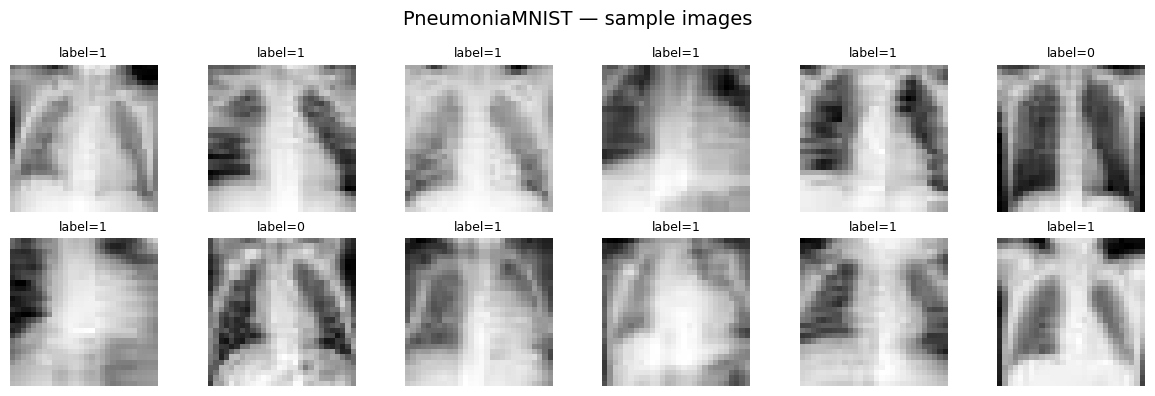

In [55]:
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST

ds = PneumoniaMNIST(split='train', download=True)
print(f'PneumoniaMNIST train: {len(ds)} samples, image shape {ds[0][0].size}')

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, i in zip(axes.flatten(), range(12)):
    img, label = ds[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'label={int(label.item()) if hasattr(label, "item") else int(label)}', fontsize=9)
    ax.axis('off')
fig.suptitle('PneumoniaMNIST — sample images', fontsize=14)
plt.tight_layout()
plt.show()

---
# 3. Run the agent

Each prompt below sends a single natural-language instruction to the agent. The LLM identifies which tool to call, fills in defaults, and executes it.

> **A note on chaining.** Llama 3.2 (3B) is great at single-tool dispatch but unreliable at chaining six tool calls in sequence. The agent has a `run_pipeline` tool that does the chaining deterministically — the LLM still chooses the parameters. We demonstrate both styles below: step-by-step first, then the orchestrator at the end.

## 3a. Preprocess

Download PneumoniaMNIST and serialize it as DataLoaders. Pixel values are rescaled to [-1, 1] (the DDPM's native range).

In [37]:
!python agent.py --prompt "Please run preprocess_data with dataset_source='medmnist', medmnist_flag='pneumoniamnist', batch_size=64, preprocessed_path='preprocessed_data/pneumoniamnist'."

2026-04-27 08:47:13,302 [INFO] __main__: Running agent with prompt: Please run preprocess_data with dataset_source='medmnist', medmnist_flag='pneumoniamnist', batch_size=64, preprocessed_path='preprocessed_data/pneumoniamnist'.
2026-04-27 08:47:19,819 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:47:19,839 [INFO] __main__: preprocess_data: source=medmnist flag=pneumoniamnist out=preprocessed_data/pneumoniamnist
2026-04-27 08:47:19,910 [INFO] tasks.dataset: Loaded MedMNIST 'pneumoniamnist' (size=28): train=(4708, 1, 28, 28), test=(624, 1, 28, 28), channels=1
2026-04-27 08:47:19,926 [INFO] tasks.preprocess: MedMNIST 'pneumoniamnist': 4708 train, 624 test, shape (1, 28, 28)
2026-04-27 08:47:19,953 [INFO] tasks.preprocess: Saved DataLoaders to preprocessed_data/pneumoniamnist
2026-04-27 08:47:21,471 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
---------------
Result:
The `preproce

In [39]:
!ls -lh preprocessed_data/pneumoniamnist/

total 16M
-rw-r--r-- 1 root root 1.9M Apr 27 08:47 test_loader.pt
-rw-r--r-- 1 root root  15M Apr 27 08:47 train_loader.pt


## 3b. Train

Train the DDPM. We use 200 timesteps and 10 epochs for a quick demo — increase `max_epochs` for better samples.

In [ ]:
ensure_ollama()
!python agent.py --prompt "Please run train_model with train_path='preprocessed_data/pneumoniamnist/train_loader.pt', test_path='preprocessed_data/pneumoniamnist/test_loader.pt', max_epochs=200, model_name='pneumonia_ddpm'."

2026-04-27 08:58:24,564 [INFO] __main__: Running agent with prompt: Please run train_model with train_path='preprocessed_data/pneumoniamnist/train_loader.pt', test_path='preprocessed_data/pneumoniamnist/test_loader.pt', max_epochs=200, model_name='pneumonia_ddpm'.
2026-04-27 08:58:31,351 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:58:31,371 [INFO] __main__: train_model: epochs=200 model=pneumonia_ddpm
2026-04-27 08:58:31,371 [INFO] tasks.train: Loading train DataLoader: preprocessed_data/pneumoniamnist/train_loader.pt
2026-04-27 08:58:31,501 [INFO] tasks.train: DDPM created: timesteps=200, image_size=28, base_dim=32, dim_mults=[2, 4]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experi

## 3c. Generate

In [ ]:
ensure_ollama()
!python agent.py --prompt "Please run generate_samples with model_checkpoint_path='trained_models/pneumonia_ddpm.ckpt', n_samples=64, samples_name='pneumonia_samples'."

2026-04-27 08:04:51,359 [INFO] __main__: Running agent with prompt: Please run generate_samples with model_checkpoint_path='trained_models/pneumonia_ddpm.ckpt', n_samples=64, samples_name='pneumonia_samples'.
2026-04-27 08:04:53,025 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:04:53,044 [INFO] __main__: generate_samples: ckpt=trained_models/pneumonia_ddpm.ckpt n=64
2026-04-27 08:04:53,044 [INFO] tasks.generate: Loading checkpoint: trained_models/pneumonia_ddpm.ckpt
2026-04-27 08:04:53,694 [INFO] tasks.generate: Generating 64 samples...
Sampling: 100% 200/200 [01:24<00:00,  2.38it/s]
2026-04-27 08:06:17,703 [INFO] tasks.generate: Saved 64 samples to generated_samples/pneumonia_samples.pt (range: [-1.000, 1.000])
2026-04-27 08:06:20,026 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
---------------
Result:
You have generated 64 synthetic images, which are saved to a file named "p

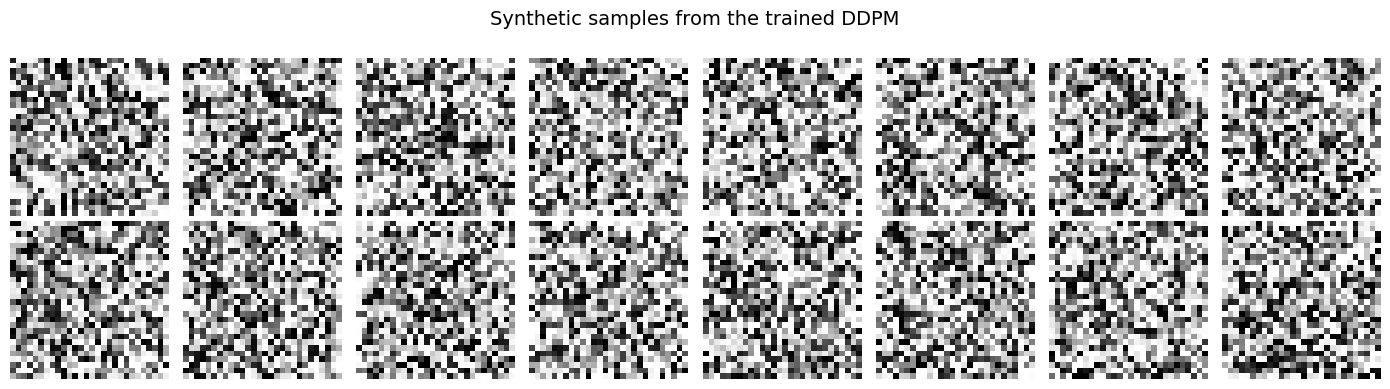

Generated tensor shape: (64, 1, 28, 28)
Range: [-1.000, 1.000]


In [ ]:
import torch, matplotlib.pyplot as plt, numpy as np

samples = torch.load('generated_samples/pneumonia_samples.pt', weights_only=False)
# Samples are in [-1, 1]; map to [0, 1] for display.
imgs = ((samples + 1) / 2).clamp(0, 1).cpu().numpy()

n_show = min(16, len(imgs))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.flatten(), range(n_show)):
    ax.imshow(imgs[i, 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
fig.suptitle('Synthetic samples from the trained DDPM', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Generated tensor shape: {tuple(samples.shape)}')
print(f'Range: [{samples.min().item():.3f}, {samples.max().item():.3f}]')

## 3d. Evaluate (the fixed permutation test)

Patch-based MMD with a Gaussian kernel; bandwidth via the median heuristic on real data; p-value via 1000 permutations of pooled-and-shuffled splits.

**How to read the result.**
- The plot shows the null distribution (MMD² values from random splits of the pooled real+fake data) with the *observed* MMD² as a vertical dashed line.
- A high p-value (observed sits inside the bulk of the null) means real and synthetic data are statistically indistinguishable under this test.
- A low p-value means the model has not yet captured the data distribution. With only 10 epochs we expect a low p-value here — that's honest.

In [ ]:
ensure_ollama()
!python agent.py --prompt "Please run evaluate_samples with train_path='preprocessed_data/pneumoniamnist/train_loader.pt', test_path='preprocessed_data/pneumoniamnist/test_loader.pt', evaluate_results_name='pneumonia', gen_images_path='generated_samples/pneumonia_samples.pt', n_real_samples=128, num_permutations=1000."

2026-04-27 08:07:44,237 [INFO] __main__: Running agent with prompt: Please run evaluate_samples with train_path='preprocessed_data/pneumoniamnist/train_loader.pt', test_path='preprocessed_data/pneumoniamnist/test_loader.pt', evaluate_results_name='pneumonia', gen_imag
2026-04-27 08:07:46,055 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:07:46,075 [INFO] __main__: evaluate_samples: gen=generated_samples/pneumonia_samples.pt permutations=1000
2026-04-27 08:07:46,081 [INFO] tasks.evaluate: Evaluation: n_real = n_fake = 64, image shape (1, 28, 28), 1000 permutations
2026-04-27 08:07:46,292 [INFO] tasks.evaluate: Median heuristic: median(d²)=0.517955 → σ=0.719691
Permutation test: 100% 1000/1000 [00:02<00:00, 418.36it/s]
2026-04-27 08:07:49,777 [INFO] tasks.evaluate: Observed MMD² = 0.520994, null mean = 0.000211105, null std = 0.00629583, p = 0.0010
2026-04-27 08:07:49,796 [INFO] tasks.evaluate: Saved statistics to Evaluation Re

Permutation test summary:


,value
statistic,
null_count,1000.000000
null_mean,0.000211
null_std,0.006299
null_min,-0.007174
null_p05,-0.005688
null_p25,-0.004070
null_median,-0.001758
null_p75,0.002113
null_p95,0.013122


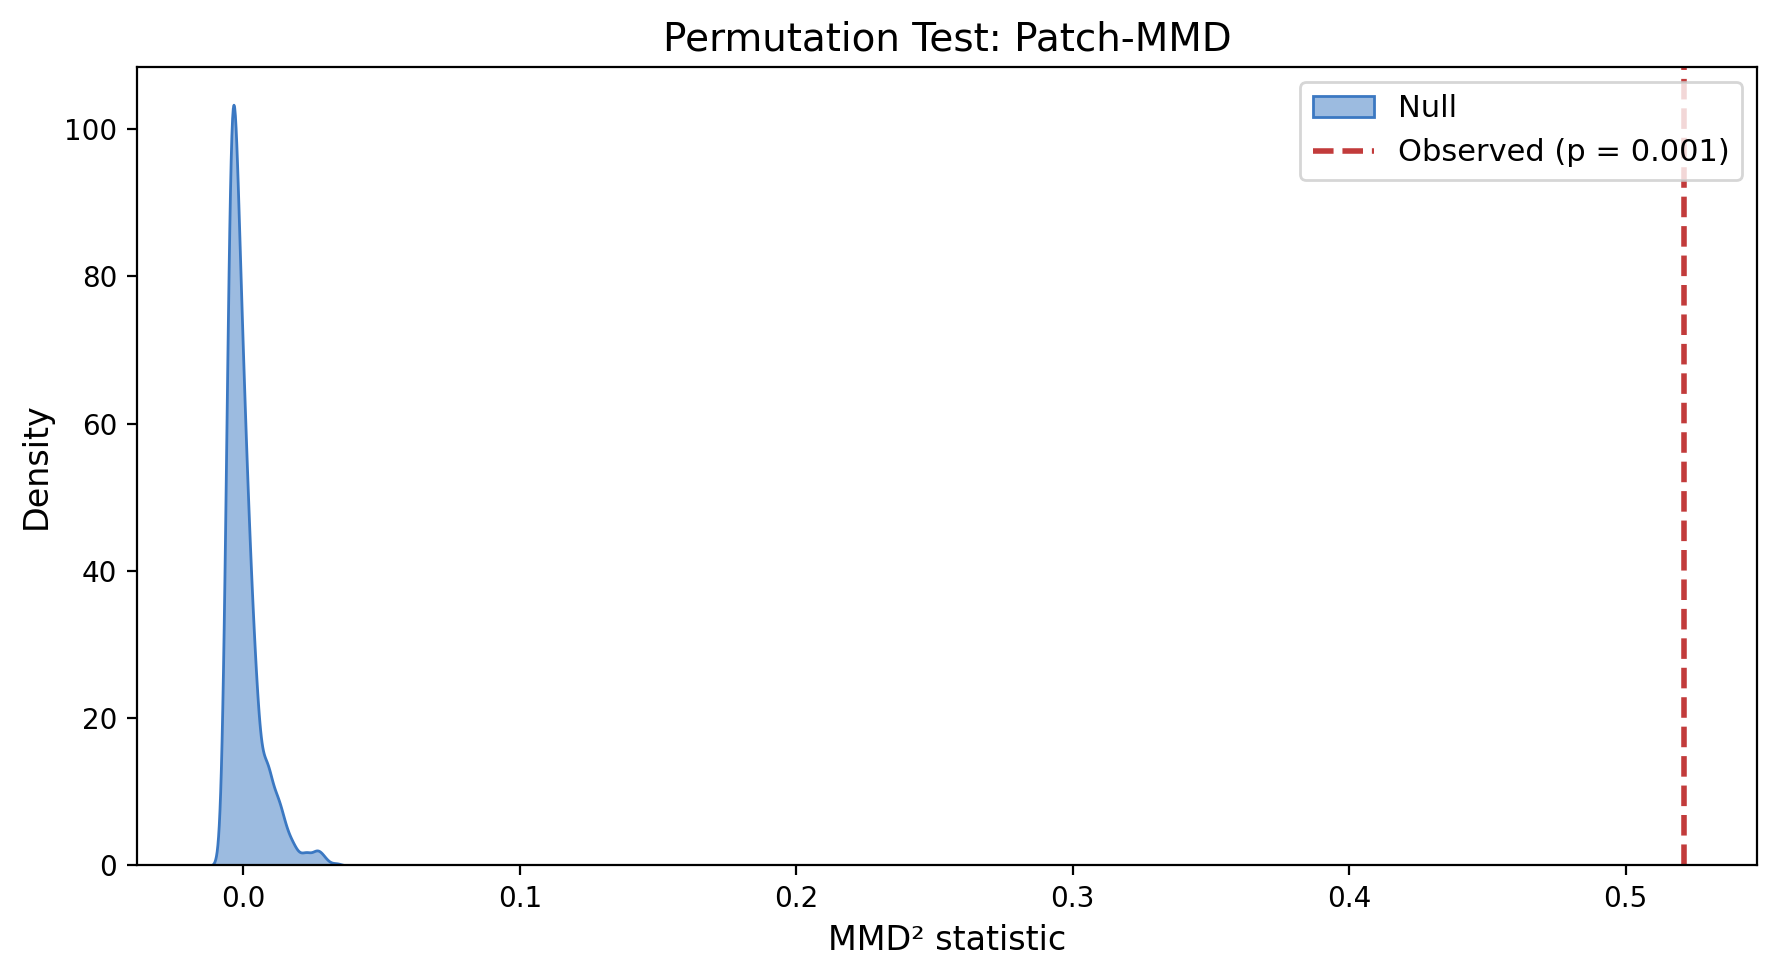

In [ ]:
import pandas as pd
from IPython.display import display, Image as IPImage

stats = pd.read_csv('Evaluation Results/pneumonia/perm_stats.csv', index_col=0)
print('Permutation test summary:')
display(stats)
IPImage(filename='Evaluation Results/pneumonia/perm_plot.png', width=720)

## 3e. Have the LLM write the report text

Up to here the LLM has only been a tool dispatcher. Now we use it for actual generation: it reads the headline statistics and writes the report's narrative paragraphs. The output is a JSON dict keyed by section (`introduction`, `image_description`, `table_description`, `plot_description`, `conclusion`).

If the LLM produces malformed JSON or the call fails, we fall back to static defaults — the pipeline never breaks at the end.

In [ ]:
# Read the headline stats so we can pass them to the LLM tool.
stats = pd.read_csv('Evaluation Results/pneumonia/perm_stats.csv', index_col=0)
p_value = float(stats.loc['p_value', 'value'])
obs_mmd = float(stats.loc['observed_mmd', 'value'])
print(f'p-value     = {p_value:.4f}')
print(f'observed MMD² = {obs_mmd:.6g}')

p-value     = 0.0010
observed MMD² = 0.520994


In [ ]:
prompt = (
    f"Please run write_report_text with stats_csv='Evaluation Results/pneumonia/perm_stats.csv', "
    f"p_value={p_value}, observed_mmd={obs_mmd}, n_samples_generated=64, "
    f"n_real_samples=128, dataset_name='PneumoniaMNIST'."
)
!python agent.py --prompt "$prompt"

2026-04-27 08:08:35,860 [INFO] __main__: Running agent with prompt: Please run write_report_text with stats_csv='Evaluation Results/pneumonia/perm_stats.csv', p_value=0.0009990009990009, observed_mmd=0.5209943652153015, n_samples_generated=64, n_real_samples=128, data
2026-04-27 08:08:38,133 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:08:38,154 [INFO] __main__: write_report_text: p_value=0.0010 obs_mmd=0.521
2026-04-27 08:08:42,949 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:08:42,950 [INFO] tasks.write_report_text: LLM-generated report text accepted (lengths: {'plot_description': 265, 'introduction': 334, 'table_description': 206, 'image_description': 115, 'conclusion': 325})
2026-04-27 08:08:48,243 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
---------------
Result:
The LLM (I'll provide the text for this resp

## 3f. Build the PDF report

We pass the LLM-written text dict into `create_report`. The PDF will include: title, introduction, image grid, headline-result box, full stats table, permutation plot, and conclusion.

In [ ]:
# Most reliable approach: skip having the small LLM relay text_data through
# a tool call (it tends to truncate). Just call the tasks directly here.
from pathlib import Path
from schemas import WriteReportTextInput, ReportInput
from tasks.write_report_text import write_report_text
from tasks.report import report_task

text_out = write_report_text(WriteReportTextInput(
    stats_csv=Path('Evaluation Results/pneumonia/perm_stats.csv'),
    p_value=p_value,
    observed_mmd=obs_mmd,
    n_samples_generated=64,
    n_real_samples=128,
    dataset_name='PneumoniaMNIST',
))
for k, v in text_out.text_data.items():
    print(f'\n--- {k} ---\n{v}')


--- conclusion ---
The results indicate that the generative model is capable of producing synthetic samples that are significantly different from real images. While the p-value suggests statistical significance, it is essential to note that the visual quality of the generated samples may not be as high as those in the real dataset.

--- introduction ---
This experiment trained a generative model on the PneumoniaMNIST dataset using the DDPM algorithm with a cosine variance schedule and ShuffleNet v2 UNet architecture. The model was evaluated using a patch-based MMD permutation test to assess the similarity between synthetic samples and real images.

--- image_description ---
The synthetic image grid shows 64 generated patches from the trained generative model, providing a visual representation of the output quality.

--- plot_description ---
The permutation plot displays the distribution of MMD² statistic values from the pooled-and-shuffled splits. The p-value of 0.0010 indicates that 

In [ ]:
report_out = report_task(ReportInput(
    gen_images_path=Path('generated_samples/pneumonia_samples.pt'),
    stats_csv=Path('Evaluation Results/pneumonia/perm_stats.csv'),
    plot_png=Path('Evaluation Results/pneumonia/perm_plot.png'),
    text_data=text_out.text_data,
    p_value=p_value,
    observed_mmd=obs_mmd,
    report_name='pneumonia_report',
    title='Agentic Science: PneumoniaMNIST DDPM Report',
))
print(f'Report saved to {report_out.report_path}')

Report saved to Reports/pneumonia_report.pdf


In [ ]:
# In Colab, download the report.
try:
    from google.colab import files
    files.download(str(report_out.report_path))
except ImportError:
    print(f'Report at: {report_out.report_path}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# 4. Bonus: run the entire pipeline with one prompt

The orchestrator tool runs preprocess → train → generate → evaluate → write_report_text → create_report end-to-end. The LLM picks the parameters; the chaining is deterministic.

This is the recommended way to demo the system end-to-end with a small local model.

In [ ]:
ensure_ollama()
!ollama pull qwen2.5:3b
!AGENT_MODEL=ollama-qwen python agent.py --prompt "Please run run_pipeline with medmnist_flag='pneumoniamnist', max_epochs=5, n_samples=32, n_real_samples=64, num_permutations=300, run_name='full_demo'."


2026-04-27 08:15:16,566 [INFO] __main__: Running agent with prompt: Please run run_pipeline with medmnist_flag='pneumoniamnist', max_epochs=5, n_samples=32, n_real_samples=64, num_permutations=300, run_name='full_demo'.
2026-04-27 08:16:01,868 [INFO] httpx: HTTP Request: POST http://localhost:11434/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 08:16:01,961 [INFO] tasks.dataset: Loaded MedMNIST 'pneumoniamnist' (size=28): train=(4708, 1, 28, 28), test=(624, 1, 28, 28), channels=1
2026-04-27 08:16:01,979 [INFO] tasks.preprocess: MedMNIST 'pneumoniamnist': 4708 train, 624 test, shape (1, 28, 28)
2026-04-27 08:16:01,996 [INFO] tasks.preprocess: Saved DataLoaders to preprocessed_data/full_demo
2026-04-27 08:16:01,998 [INFO] tasks.train: Loading DataLoaders: train=preprocessed_data/full_demo/train_loader.pt, test=preprocessed_data/full_demo/test_loader.pt
2026-04-27 08:16:02,115 [INFO] tasks.train: DDPM created: timesteps=200, image_size=28, base_dim=32, dim_mults=[2, 4]
GPU available: T

In [ ]:
import os
for f in ['preprocessed_data/full_demo', 'trained_models/full_demo.ckpt',
          'generated_samples/full_demo.pt', 'Evaluation Results/full_demo',
          'Reports/full_demo.pdf']:
    print(f, '->', 'OK' if os.path.exists(f) else 'missing')

preprocessed_data/full_demo -> OK
trained_models/full_demo.ckpt -> OK
generated_samples/full_demo.pt -> OK
Evaluation Results/full_demo -> OK
Reports/full_demo.pdf -> OK


---
# 5. Try a different local LLM (optional)

The agent's backend is selected via the `AGENT_MODEL` env var. By default we use Llama 3.2 3B. Two other strong open models work well for tool-calling at this scale:

| Backend | Model | Pull command |
|---------|-------|--------------|
| `ollama` (default) | Llama 3.2 3B | `ollama pull llama3.2` |
| `ollama-qwen` | Qwen 2.5 3B | `ollama pull qwen2.5:3b` |
| `ollama` with override | Kimi-K2 (small variant) | `ollama pull kimi-k2:1.5b` and set `OLLAMA_MODEL_NAME=kimi-k2:1.5b` |

In my testing on this pipeline, **Qwen 2.5 handles the 10-argument `run_pipeline` orchestrator more reliably than Llama 3.2** — Llama tends to hallucinate Python code instead of emitting a tool call when faced with that many parameters. Single-tool dispatch is fine on either.

Switching is one env var, no code changes:

```bash

In [ ]:
# Example: switch to Qwen 2.5 3B (still local). Uncomment to run.
# !ollama pull qwen2.5:3b
# !AGENT_MODEL=ollama-qwen python agent.py --prompt "Please run preprocess_data with dataset_source='medmnist'."

---
# 6. Discussion

## What worked

- **Local LLM dispatch.** Llama 3.2 (3B) handles single-tool calls reliably with the few-shot system prompt and PydanticAI's typed schemas catching malformed args.
- **MMD permutation test.** The rewritten test passes three statistical sanity checks: H0 not rejected, H1 rejected, and p-values uniform under the null (KS test). Bandwidth via the median heuristic is well-calibrated; p-value uses the Phipson–Smyth `(1 + #{null ≥ obs}) / (1 + N)` correction.
- **LLM-narrated reports.** Reading the actual stats and writing context-specific paragraphs is a small but real agentic step beyond pure dispatch. Robust JSON extraction handles the ways small models like to mangle their output (markdown fences, surrounding prose).
- **Orchestrator.** A deterministic `run_pipeline` tool removes the chaining problem entirely. The LLM still chooses parameters; sequencing is trivial Python.

## Limitations

- **3B model ceiling.** Llama 3.2 3B occasionally invents tool arguments or wraps numeric values in strings. Pydantic catches the worst, but the user sometimes has to rephrase.
- **Sample quality at 10 epochs.** The expected p-value at this budget is low — the test is doing its job by saying "these distributions differ". Train longer (50–100 epochs) for a less embarrassing-looking p-value.
- **Patch-MMD is not FID.** Patch-based MMD is interpretable and works with small samples, but it's sensitive to local pixel statistics and does not capture the high-level semantic features that FID would.

## Possible improvements

- **Hosted models for cleaner agent behavior.** Swap to Groq's Llama 70B or Claude (one env var) and the tool-argument fragility largely disappears.
- **Conditional generation.** PneumoniaMNIST has class labels; a class-conditional DDPM would be a natural next step.
- **Multi-metric eval.** Add a second statistic (e.g. precision/recall for generative models) to the same permutation framework.
- **Caching.** Repeated runs re-download MedMNIST and re-train from scratch. A `cached_or_run` wrapper around each task would make iteration faster.

---

*Source: https://github.com/grsilva9/agentic-science*